In [10]:
import pandas as pd

url = "https://github.com/digital-wellbeing/open-play/raw/v1.2.6/data/clean/survey_biweekly.csv.gz"
survey = pd.read_csv(url, low_memory=False)

print(survey.shape)

(6844, 158)


Each line corresponds to a questionnaire filled out by a player. The same player can therefore have several lines, since he has replied several times.

In [11]:
#keeps only the columns we want to look at (pid is the player’s identifier)
survey[["pid", "recent_session1_time", "recent_session1_duration_min"]].head() #displays only the first 5 lines, to take a look.

,pid,recent_session1_time,recent_session1_duration_min
0,p100362329,20:00:00,180.0
1,p1009647790,23:45:00,30.0
2,p1009647790,13:00:00,60.0
3,p1009647790,19:00:00,120.0
4,p1009647790,00:00:00,60.0


In [12]:
# Start time, converted to minutes after midnight
time = pd.to_datetime(survey["recent_session1_time"], format="%H:%M:%S", errors="coerce")
start = time.dt.hour * 60 + time.dt.minute

# End time = start + duration
end = start + survey["recent_session1_duration_min"]

# Night session: starts before 6 am OR ends after midnight
survey["night"] = ((start < 360) | (end > 1440)).where(start.notna())

survey["night"].value_counts(dropna=False)

night
False    5426
True      939
NaN       479
Name: count, dtype: int64

We know that 15% of parties are "night parties" and are  doing between 00h and 6h

### Mental wellbeing score (WEMWBS)

In each survey, players rated 7 statements about the **last 2 weeks**.
Answers go from **1 = none of the time** to **5 = all of the time**.

| Column | Statement |
|---|---|
| `wemwbs_1` | I've been feeling optimistic about the future |
| `wemwbs_2` | I've been feeling relaxed |
| `wemwbs_3` | I've been thinking clearly |
| `wemwbs_4` | I've been feeling close to other people |
| `wemwbs_5` | I've been able to make up my own mind about things |
| `wemwbs_6` | I've been feeling useful |
| `wemwbs_7` | I've been dealing with problems well |

**Score = sum of the 7 answers**, from **7** (lowest wellbeing) to **35** (highest wellbeing).
The score is only computed when all 7 answers are present.
Possible answers: 1 = never, 2 = rarely, 3 = sometimes, 4 = often, 5 = all the time.

In [13]:
# Wellbeing score = sum of the 7 answers (only if all 7 are answered)
wellbeing_items = ["wemwbs_1", "wemwbs_2", "wemwbs_3", "wemwbs_4",
                   "wemwbs_5", "wemwbs_6", "wemwbs_7"]
survey["wellbeing"] = survey[wellbeing_items].sum(axis=1, min_count=7)

survey["wellbeing"].describe()

count    6686.000000
mean       23.259198
std         5.261364
min         7.000000
25%        20.000000
50%        23.000000
75%        27.000000
max        35.000000
Name: wellbeing, dtype: float64

In [14]:
# One row per player: average over all their surveys
players = survey.groupby("pid")[["night", "wellbeing"]].mean().dropna()

print(len(players), "players")
players.head()

1784 players


,night,wellbeing
pid,,
p100362329,0.0,23.000000
p1009647790,0.4,20.000000
p1009727917,0.0,23.166667
p1018587010,1.0,25.000000
p1032030571,0.0,22.333333


**One row per player**

Each player answered the survey several times (up to 6). To give every player the same
weight, we average their answers:

- `wellbeing` = the player's **average wellbeing score** over all their surveys;
- `night` = the **share of their reported sessions that were played at night**
  (True counts as 1 and False as 0, so the average is a proportion).

We end up with **1,784 players**.

*Examples:*
- player `p1009647790`: `night = 0.4` → 40% of their reported sessions were at night
  (e.g. 2 out of 5); average wellbeing 20 / 35;
- player `p1018587010`: `night = 1.0` → **all** their reported sessions were at night,
  yet their wellbeing is 25 / 35, above average.

These two examples show that individual players vary a lot: one player alone tells us nothing.
This is why, in the next step, we **group players** and compare **group averages**.

In [15]:
# Put each player in a group according to their share of night sessions
players["group"] = pd.cut(players["night"], bins=[-0.01, 0, 1/3, 1],
                          labels=["Never", "Sometimes", "Often"])

# Average wellbeing and number of players in each group
summary = players.groupby("group", observed=True)["wellbeing"].agg(["mean", "count"])
summary

,mean,count
group,,
Never,23.522277,1227
Sometimes,22.897365,291
Often,22.588910,266


**Reading the groups**

The more often players game at night, the lower their average wellbeing:
**23.5** (never) → **22.9** (sometimes) → **22.6** (often), out of 35.

Most players (1,227) never reported a night session; about 290 do it sometimes
and about 270 often.

In [16]:
# Margin of error (95% confidence interval) for each group's average
summary = players.groupby("group", observed=True)["wellbeing"].agg(["mean", "count", "sem"])
summary["margin"] = 1.96 * summary["sem"]
summary["low"] = summary["mean"] - summary["margin"]
summary["high"] = summary["mean"] + summary["margin"]
summary.round(2)

,mean,count,sem,margin,low,high
group,,,,,,
Never,23.52,1227,0.14,0.27,23.25,23.79
Sometimes,22.90,291,0.27,0.53,22.36,23.43
Often,22.59,266,0.27,0.54,22.05,23.13


**Is the difference real?**

For each group we compute a **95% confidence interval**: the range where the true
average very likely lies (mean ± 1.96 × standard error).

- Never: 23.25 – 23.79
- Sometimes: 22.36 – 23.43
- Often: 22.05 – 23.13

The intervals of **Never** and **Often** do not overlap (23.25 > 23.13):
the gap between players who never game at night and those who often do is
**unlikely to be due to chance**. 
The "Sometimes" group sits in between.
The difference is **small** (about 1 point out of 35) and it is an **association**, not a proof that night gaming causes lower wellbeing.

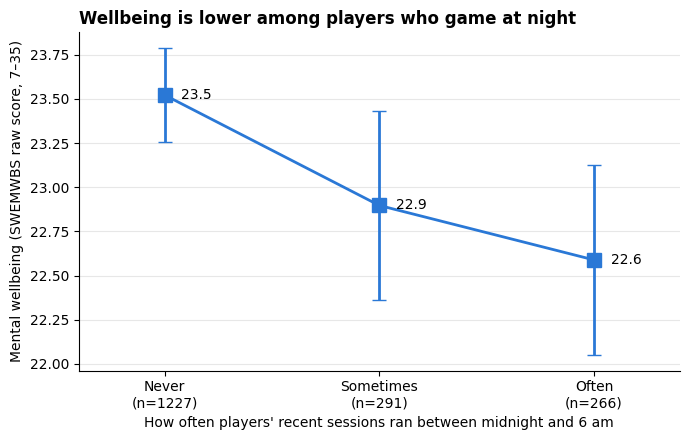

In [17]:
import matplotlib.pyplot as plt

groups = summary.index.astype(str)
fig, ax = plt.subplots(figsize=(7, 4.5))

# Points = group averages, vertical bars = 95% confidence intervals
ax.errorbar(groups, summary["mean"], yerr=summary["margin"],
            fmt="s-", color="#2a78d6", markersize=10, capsize=5, linewidth=2)

# Write each average next to its point
for i, mean in enumerate(summary["mean"]):
    ax.annotate(f"{mean:.1f}", (i, mean), xytext=(12, 0),
                textcoords="offset points", va="center")

# Group names + number of players under each point
ax.set_xticks(range(len(groups)), [f"{g}\n(n={n})" for g, n in zip(groups, summary["count"])])
ax.set_xlim(-0.4, len(groups) - 0.6)

# Titles and style
ax.set_title("Wellbeing is lower among players who game at night", loc="left", fontweight="bold")
ax.set_xlabel("How often players' recent sessions ran between midnight and 6 am")
ax.set_ylabel("Mental wellbeing (SWEMWBS raw score, 7–35)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Chart: night gaming and wellbeing**

Each square is the average wellbeing of a group of players; the vertical bars are the
95% confidence intervals. Wellbeing goes down from **23.5** (never at night) to
**22.6** (often at night). The bars of "Never" and "Often" do not overlap, so the gap is
unlikely to be due to chance, but it remains small (about 1 point out of 35).